# **Setup & Import Libraries**

In [ ]:
# Import all required libraries for data cleaning, augmentation, splitting, and visualization
import os
import shutil
import random
from glob import glob

import numpy as np
from tqdm import tqdm
from PIL import Image
import cv2

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img

import math


import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Define Dataset Paths

In [ ]:
#original dataset
ORIG_DATASET_DIR = "/content/drive/MyDrive/AI_System_Design/Gym_Dataset_Before_Processing"
#cleaned dataset
CLEAN_DATASET_DIR = "/content/drive/MyDrive/AI_System_Design/Clean_Gym_Dataset"
#final dataset
FINAL_DATASET_DIR = "/content/drive/MyDrive/AI_System_Design/Dataset_V10"

os.makedirs(CLEAN_DATASET_DIR, exist_ok=True)
os.makedirs(FINAL_DATASET_DIR, exist_ok=True)

# Detect Class Names

In [ ]:
classes = sorted([
    d for d in os.listdir(ORIG_DATASET_DIR)
    if os.path.isdir(os.path.join(ORIG_DATASET_DIR, d))
])

print("Detected Classes:")
for c in classes:
    print(" -", c)

Detected Classes:
 - barbell
 - bench-press
 - dumbell
 - kattle-ball
 - leg-press
 - punching-bag
 - roller-abs
 - statis-bicycle
 - step
 - treadmill


# Clean Images


## Global Parameters

In [ ]:
IMG_SIZE = (224, 224)
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## Cleaning

In [ ]:
valid_exts = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

for cls in classes:
    src_folder = os.path.join(ORIG_DATASET_DIR, cls)
    dst_folder = os.path.join(CLEAN_DATASET_DIR, cls)
    os.makedirs(dst_folder, exist_ok=True)

    image_paths = []
    for ext in valid_exts:
        image_paths.extend(glob(os.path.join(src_folder, f"*{ext}")))
        image_paths.extend(glob(os.path.join(src_folder, f"*{ext.upper()}")))

    print(f"\n[Cleaning] Class: {cls} | {len(image_paths)} images found")

    idx = 0
    for img_path in tqdm(image_paths):
        try:
            img = Image.open(img_path).convert("RGB")

            # Remove small images
            w, h = img.size
            if min(w, h) < 80:
                print("  -> Skipped small image:", img_path)
                continue
            # Resize
            img = img.resize(IMG_SIZE, Image.BILINEAR)
            # Convert to JPG and Rename it based on class name and index
            new_name = f"{cls}_{idx:05d}.jpg"
            img.save(os.path.join(dst_folder, new_name), "JPEG", quality=90)
            idx += 1

        except Exception as e:
            print("Error loading image:", img_path, "|", e)

    print(f"[Cleaning Done] Class: {cls} -> {idx} images saved.")



[Cleaning] Class: barbell | 50 images found


100%|██████████| 50/50 [00:01<00:00, 27.67it/s]


[Cleaning Done] Class: barbell -> 50 images saved.

[Cleaning] Class: bench-press | 61 images found


100%|██████████| 61/61 [00:01<00:00, 39.95it/s]


[Cleaning Done] Class: bench-press -> 61 images saved.

[Cleaning] Class: dumbell | 50 images found


...

[Cleaning Done] Class: statis-bicycle -> 50 images saved.

[Cleaning] Class: step | 49 images found


100%|██████████| 49/49 [00:00<00:00, 51.92it/s]


[Cleaning Done] Class: step -> 49 images saved.

[Cleaning] Class: treadmill | 50 images found


100%|██████████| 50/50 [00:02<00:00, 24.90it/s]

[Cleaning Done] Class: treadmill -> 50 images saved.


# Split Dataset into Train / Val / Test

In [ ]:
SPLIT_TRAIN = 0.6
SPLIT_VAL   = 0.2
SPLIT_TEST  = 0.2

assert abs((SPLIT_TRAIN + SPLIT_VAL + SPLIT_TEST) - 1.0) < 1e-6

# Prepare split folders
train_dir = os.path.join(FINAL_DATASET_DIR, "train")
val_dir   = os.path.join(FINAL_DATASET_DIR, "val")
test_dir  = os.path.join(FINAL_DATASET_DIR, "test")

for d in [train_dir, val_dir, test_dir]:
    os.makedirs(d, exist_ok=True)

print("Starting dataset split...\n")

for cls in classes:

    cls_src = os.path.join(CLEAN_DATASET_DIR, cls)
    images = sorted(glob(os.path.join(cls_src, "*.jpg")))

    total = len(images)
    if total == 0:
        print(f" No images found for class: {cls}")
        continue

    # First split: Train vs (Val+Test)
    train_imgs, temp_imgs = train_test_split(
        images,
        test_size=(1 - SPLIT_TRAIN),
        random_state=RANDOM_SEED,
        shuffle=True
    )

    # Second split: Val vs Test
    val_ratio = SPLIT_VAL / (SPLIT_VAL + SPLIT_TEST)
    val_imgs, test_imgs = train_test_split(
        temp_imgs,
        test_size=(1 - val_ratio),
        random_state=RANDOM_SEED,
        shuffle=True
    )

    # Create class folders inside splits
    split_map = [
        (train_dir, train_imgs),
        (val_dir,   val_imgs),
        (test_dir,  test_imgs)
    ]

    for split_path, img_list in split_map:
        dst = os.path.join(split_path, cls)
        os.makedirs(dst, exist_ok=True)

        for img in img_list:
            shutil.copy(img, os.path.join(dst, os.path.basename(img)))

    # Print class stats
    print(f"{cls}:")
    print(f"  Train = {len(train_imgs)}")
    print(f"  Val   = {len(val_imgs)}")
    print(f"  Test  = {len(test_imgs)}")
    print(f"  Total = {total}")
    print("-" * 40)


Starting dataset split...

barbell:
  Train = 30
  Val   = 10
  Test  = 10
  Total = 50
----------------------------------------
bench-press:
  Train = 36
  Val   = 12
  Test  = 13
  Total = 61
----------------------------------------
dumbell:
  Train = 30
  Val   = 10
  Test  = 10
  Total = 50
----------------------------------------
kattle-ball:
  Train = 30
  Val   = 10
  Test  = 10
  Total = 50
----------------------------------------
leg-press:
  Train = 30
  Val   = 10
  Test  = 10
  Total = 50
----------------------------------------
punching-bag:
  Train = 29
  Val   = 10
  Test  = 10
  Total = 49
----------------------------------------
roller-abs:
  Train = 30
  Val   = 10
  Test  = 10
  Total = 50
----------------------------------------
statis-bicycle:
  Train = 30
  Val   = 10
  Test  = 10
  Total = 50
----------------------------------------
step:
  Train = 29
  Val   = 10
  Test  = 10
  Total = 49
----------------------------------------
treadmill:
  Train = 30
  Val   =

In [ ]:
import os
from glob import glob

train_dir = os.path.join(FINAL_DATASET_DIR, "train")
val_dir = os.path.join(FINAL_DATASET_DIR, "val")
test_dir = os.path.join(FINAL_DATASET_DIR, "test")

for cls in classes:
    train_c = len(glob(os.path.join(train_dir, cls, "*.jpg")))
    val_c = len(glob(os.path.join(val_dir, cls, "*.jpg")))
    test_c = len(glob(os.path.join(test_dir, cls, "*.jpg")))

    print(f"{cls}:  train={train_c}   val={val_c}   test={test_c}   (total={train_c + val_c + test_c})")


barbell:  train=30   val=10   test=10   (total=50)
bench-press:  train=36   val=12   test=13   (total=61)
dumbell:  train=30   val=10   test=10   (total=50)
kattle-ball:  train=30   val=10   test=10   (total=50)
leg-press:  train=30   val=10   test=10   (total=50)
punching-bag:  train=29   val=10   test=10   (total=49)
roller-abs:  train=30   val=10   test=10   (total=50)
statis-bicycle:  train=30   val=10   test=10   (total=50)
step:  train=29   val=10   test=10   (total=49)
treadmill:  train=30   val=10   test=10   (total=50)


# Data Augmentation for TRAIN

In [ ]:
AUG_PER_IMAGE = 2   # Number of images to each image (triple)

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    brightness_range=[0.8, 1.2],
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

print("\n[Augmentation] Starting...")

train_base = os.path.join(FINAL_DATASET_DIR, "train")

classes_in_train = sorted([
    d for d in os.listdir(train_base)
    if os.path.isdir(os.path.join(train_base, d))
])

for cls in classes_in_train:
    cls_path = os.path.join(train_base, cls)
    img_paths = glob(os.path.join(cls_path, "*.jpg"))

    print(f"\nClass: {cls} | Train images: {len(img_paths)}")

    for img_path in tqdm(img_paths):
        try:
            img = load_img(img_path, target_size=IMG_SIZE)
            x = img_to_array(img)
            x = np.expand_dims(x, axis=0)

            i = 0
            for batch in datagen.flow(
                x,
                batch_size=1,
                save_to_dir=cls_path,
                save_prefix="aug",
                save_format="jpg"
            ):
                i += 1
                if i >= AUG_PER_IMAGE:
                    break

        except Exception as e:
            print("Aug error:", img_path, "|", e)



[Augmentation] Starting...

Class: barbell | Train images: 30


100%|██████████| 30/30 [00:01<00:00, 17.35it/s]



Class: bench-press | Train images: 36


100%|██████████| 36/36 [00:02<00:00, 17.63it/s]



Class: dumbell | Train images: 30


...

100%|██████████| 30/30 [00:01<00:00, 17.00it/s]



Class: step | Train images: 29


100%|██████████| 29/29 [00:01<00:00, 17.71it/s]



Class: treadmill | Train images: 30


100%|██████████| 30/30 [00:01<00:00, 17.20it/s]


# Dataset Statistics Summary


## Table: Image Count per Class (Train / Val / Test / Total)


In [ ]:
classes = sorted(os.listdir(train_dir))

rows = []

for cls in classes:
    train_count = len(glob(os.path.join(train_dir, cls, "*.jpg")))
    val_count   = len(glob(os.path.join(val_dir, cls, "*.jpg")))
    test_count  = len(glob(os.path.join(test_dir, cls, "*.jpg")))

    total = train_count + val_count + test_count

    rows.append([cls, train_count, val_count, test_count, total])

pivot_df = pd.DataFrame(rows, columns=["Class", "train", "val", "test", "total"])

pivot_df


,Class,train,val,test,total
0,barbell,90,10,10,110
1,bench-press,108,12,13,133
2,dumbell,90,10,10,110
3,kattle-ball,90,10,10,110
4,leg-press,90,10,10,110
5,punching-bag,87,10,10,107
6,roller-abs,90,10,10,110
7,statis-bicycle,90,10,10,110
8,step,87,10,10,107
9,treadmill,90,10,10,110


## Figure: Number of Images per Class (TRAIN Only)

/tmp/ipython-input-1282384170.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


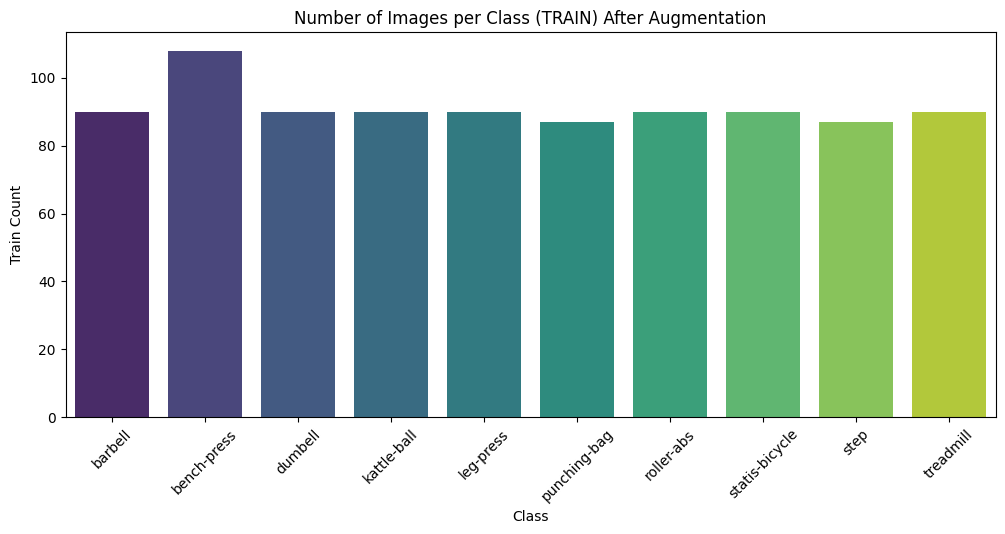

In [ ]:
plt.figure(figsize=(12, 5))
sns.barplot(
    x=pivot_df["Class"],
    y=pivot_df["train"],
    palette="viridis"
)

plt.title("Number of Images per Class (TRAIN) After Augmentation")
plt.xlabel("Class")
plt.ylabel("Train Count")
plt.xticks(rotation=45)
plt.show()

## Show random samples (TRAIN)

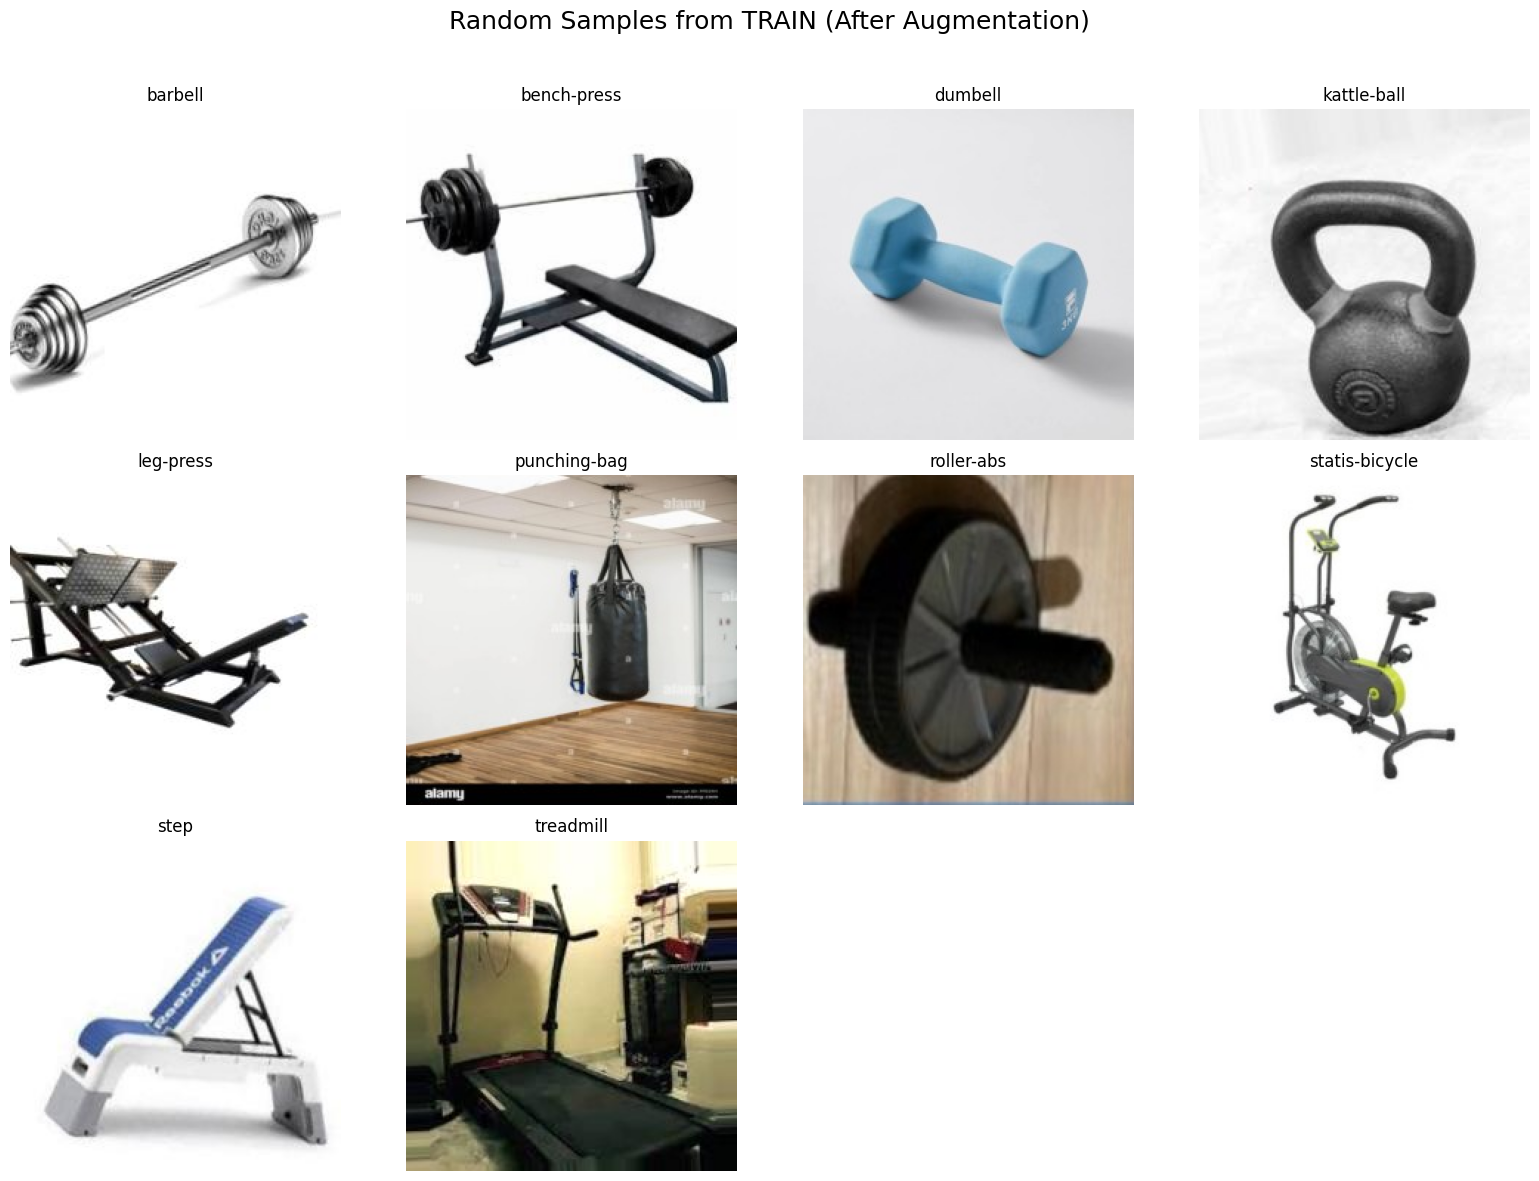

In [ ]:
train_dir = os.path.join(FINAL_DATASET_DIR, "train")
all_classes = sorted(os.listdir(train_dir))

num_classes = len(all_classes)

# Auto-calc grid size
cols = 4
rows = math.ceil(num_classes / cols)

plt.figure(figsize=(16, rows * 4))

i = 1
for cls in all_classes:
    cls_dir = os.path.join(train_dir, cls)
    imgs = glob(os.path.join(cls_dir, "*.jpg"))

    if len(imgs) == 0:
        continue

    sample = random.choice(imgs)
    img = Image.open(sample)

    plt.subplot(rows, cols, i)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
    i += 1

plt.suptitle("Random Samples from TRAIN (After Augmentation)", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## **Summary Report**

In [ ]:
total_train = sum(len(glob(os.path.join(train_dir, cls, "*.jpg")))
                  for cls in os.listdir(train_dir))
total_val = sum(len(glob(os.path.join(val_dir, cls, "*.jpg")))
                for cls in os.listdir(val_dir))
total_test = sum(len(glob(os.path.join(test_dir, cls, "*.jpg")))
                 for cls in os.listdir(test_dir))

print(" Dataset Summary Report")
print("Total TRAIN images:", total_train)
print("Total VAL images  :", total_val)
print("Total TEST images :", total_test)


print("\nImages per class (TRAIN):")

for cls in sorted(os.listdir(train_dir)):
    cls_path = os.path.join(train_dir, cls)
    count = len(glob(os.path.join(cls_path, "*.jpg")))
    print(f"{cls} : {count}")

 Dataset Summary Report
Total TRAIN images: 912
Total VAL images  : 102
Total TEST images : 103

Images per class (TRAIN):
barbell : 90
bench-press : 108
dumbell : 90
kattle-ball : 90
leg-press : 90
punching-bag : 87
roller-abs : 90
statis-bicycle : 90
step : 87
treadmill : 90
